In [19]:
#Using AI
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

df = pd.read_csv(
    'training.1600000.processed.noemoticon.csv',
    encoding='latin-1',
    header=None,
    names=['sentiment','id','date','query','user','text'],
    on_bad_lines='skip'
)

df['sentiment'] = df['sentiment'].map({0: 0, 4: 1})

df.dropna(subset=['text', 'sentiment'], inplace=True)

vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    max_df=0.5,
    min_df=5,
    stop_words='english'
)

X = vectorizer.fit_transform(df['text'])

X_train, X_test, y_train, y_test=train_test_split(
    X, df['sentiment'],
    train_size=0.1,
    test_size=0.02,
    random_state=20,
    stratify=df['sentiment']
)

In [20]:
display(df)

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...,...
1599995,1,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,1,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,1,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,1,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...



Random Forest Accuracy: 0.7304

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.66      0.71     16000
    Positive       0.70      0.80      0.75     16000

    accuracy                           0.73     32000
   macro avg       0.73      0.73      0.73     32000
weighted avg       0.73      0.73      0.73     32000



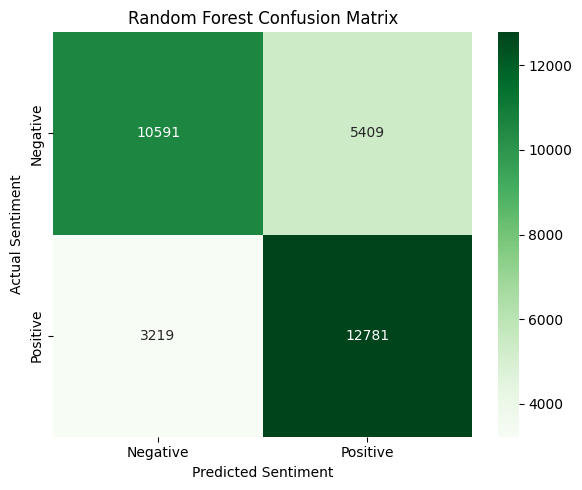

In [21]:
#Using AI
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    max_depth=15,
    min_samples_leaf= 5,
    random_state =42
)

rf.fit(X_train, y_train)

predict_rf=rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, predict_rf)
report_rf= classification_report(y_test, predict_rf,target_names =['Negative', 'Positive'])
cm_rf = confusion_matrix(y_test, predict_rf)

print(f"\nRandom Forest Accuracy: {accuracy_rf:.4f}")
print("\nClassification Report:")
print(report_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

First, I imported the libraries I needed to perform the Random Forest model. I then initialized the RandomForestClassifier with the number of trees (100) and the max depth of each tree (15). Next, I trained the model with the twitter data and sentiment labels, and I made predictions on the test set (twitter data). Then, I created a classification report, which shows the precision, recall, and overall accuracy for each class. The confusion matrix visualizes the precision and recall. The overall accuracy was 0.7304, which is relatively low. A lot of predicted positives were actually negative.